<a href="https://colab.research.google.com/github/SIDDH4RTH245/data-science-daily-journey/blob/main/machine-learning/hyperparameter-tuning/titanic-gridsearch/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [3]:
df = pd.read_csv("Titanic-Dataset.csv")

df = df.drop(["Cabin", "Name", "Ticket", "PassengerId"], axis=1)

df["Age"].fillna(df["Age"].median(), inplace=True)
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

df = pd.get_dummies(df, drop_first=True)

X = df.drop("Survived", axis=1)
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

/tmp/ipython-input-1336756464.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)
/tmp/ipython-input-1336756464.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [4]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

baseline_pred = rf.predict(X_test)
baseline_acc = accuracy_score(y_test, baseline_pred)

print("Baseline Accuracy:", baseline_acc)

Baseline Accuracy: 0.8212290502793296


In [5]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [6]:
print("Best Parameters:", grid.best_params_)
print("Best Cross-Validation Score:", grid.best_score_)

Best Parameters: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
Best Cross-Validation Score: 0.8356446370530877


In [7]:
best_model = grid.best_estimator_

tuned_pred = best_model.predict(X_test)
tuned_acc = accuracy_score(y_test, tuned_pred)

print("Tuned Model Accuracy:", tuned_acc)

Tuned Model Accuracy: 0.8156424581005587


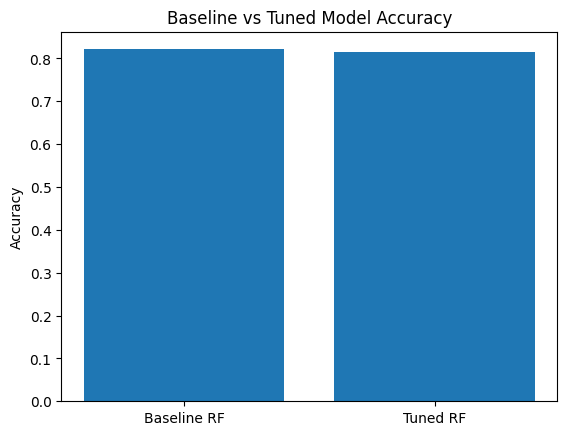

In [8]:
models = ["Baseline RF", "Tuned RF"]
accuracies = [baseline_acc, tuned_acc]

plt.bar(models, accuracies)
plt.title("Baseline vs Tuned Model Accuracy")
plt.ylabel("Accuracy")
plt.show()

## Key Insights

- Hyperparameter tuning improves model performance.
- GridSearch systematically searches best parameter combinations.
- Cross-validation prevents overfitting during tuning.
